In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sys.path.append("..")
from utils.similarity import (
    get_feature_columns,
    compute_group_centroids,
    group_cosine_similarity,
    group_distance_matrix,
    group_correlation_matrix,
    top_similar_pairs,
    top_dissimilar_pairs,
    feature_wise_group_deviation,
)

sns.set_theme(style="whitegrid")


In [2]:
DATA_PATH = Path("../data/extracted/rhythm_features.parquet")
rhythm_df = pd.read_parquet(DATA_PATH)
rhythm_df.shape


(109089, 41)

In [3]:
rhythm_df.head()


,genre,state,artist,gender,song,source,source_file,energy_mean,energy_std,energy_max,...,rhythm_hist_std,tempogram_dominant_lag,tempogram_stability,tempogram_mean_energy,tempogram_var,onset_mean,onset_std,onset_max,onset_peak_count,onset_density
0,Bauls,West Bengal,Babul Supriyo,Male,Sundori Kamala,https://gaana.com/song/sundori-kamala-1,Bauls_clean.pkl,-6664.115234,1794.571289,-4018.647217,...,0.080684,1.0,1.000000e+10,0.015152,0.087408,296.212219,549.835083,3057.824219,13.0,0.100775
1,Bauls,West Bengal,Babul Supriyo,Male,Sundori Kamala,https://gaana.com/song/sundori-kamala-1,Bauls_clean.pkl,-6034.185547,988.613953,-4096.845703,...,0.019924,1.0,1.000000e+10,0.015152,0.080058,329.697266,559.271729,2703.819336,14.0,0.108527
2,Bauls,West Bengal,Babul Supriyo,Male,Sundori Kamala,https://gaana.com/song/sundori-kamala-1,Bauls_clean.pkl,-5896.586426,977.628967,-3886.344971,...,0.019915,1.0,1.000000e+10,0.015152,0.077731,328.702515,526.732056,2139.476562,16.0,0.124031
3,Bauls,West Bengal,Babul Supriyo,Male,Sundori Kamala,https://gaana.com/song/sundori-kamala-1,Bauls_clean.pkl,-5900.519043,1017.549377,-3920.866699,...,0.021060,1.0,1.000000e+10,0.015152,0.074588,331.991638,526.898865,2011.021484,16.0,0.124031
4,Bauls,West Bengal,Babul Supriyo,Male,Sundori Kamala,https://gaana.com/song/sundori-kamala-1,Bauls_clean.pkl,-5906.877930,991.570679,-3973.443115,...,0.022325,1.0,1.000000e+10,0.015152,0.074591,341.991150,556.537292,2182.362305,15.0,0.116279


In [4]:
feature_cols = get_feature_columns(rhythm_df)
len(feature_cols), feature_cols


(34,
 ['energy_mean',
  'energy_std',
  'energy_max',
  'energy_min',
  'energy_range',
  'energy_skew',
  'flux_mean',
  'flux_std',
  'flux_max',
  'flux_sum',
  'ac_peak_lag',
  'ac_peak_value',
  'ac_mean',
  'ac_std',
  'temporal_entropy',
  'frame_entropy_mean',
  'frame_entropy_std',
  'modulation_dominant_freq_bin',
  'modulation_dominant_mag',
  'modulation_energy',
  'modulation_centroid',
  'rhythm_hist_dominant_bin',
  'rhythm_hist_dominant_value',
  'rhythm_hist_entropy',
  'rhythm_hist_std',
  'tempogram_dominant_lag',
  'tempogram_stability',
  'tempogram_mean_energy',
  'tempogram_var',
  'onset_mean',
  'onset_std',
  'onset_max',
  'onset_peak_count',
  'onset_density'])

In [5]:
rhythm_df["genre"].value_counts()


genre
Kajri           20580
Sufi            19213
Maand           17796
Uttarakhandi    13020
Sohar           12994
Bhatiali         8808
Bauls            8450
Gidha            8228
Name: count, dtype: int64

In [6]:
rhythm_df["state"].value_counts()


state
Uttar Pradesh     33574
Northern India    19213
Rajasthan         17796
West Bengal       17258
Uttarakhand       13020
Punjab             8228
Name: count, dtype: int64

In [7]:
genre_centroids, _ = compute_group_centroids(rhythm_df, group_col="genre")
genre_centroids


,energy_mean,energy_std,energy_max,energy_min,energy_range,energy_skew,flux_mean,flux_std,flux_max,flux_sum,...,rhythm_hist_std,tempogram_dominant_lag,tempogram_stability,tempogram_mean_energy,tempogram_var,onset_mean,onset_std,onset_max,onset_peak_count,onset_density
genre,,,,,,,,,,,,,,,,,,,,,
Bauls,-0.462616,0.087359,-0.482279,-0.462199,0.149431,-0.145412,-0.027991,-0.047243,0.039478,-0.027991,...,0.153925,0.000617,0.0,-0.002636,0.116203,-0.090794,-0.054396,0.029643,-0.166784,-0.166784
Bhatiali,-0.385283,-0.096207,-0.480450,-0.190978,-0.194995,0.181192,-0.523511,-0.480756,-0.430280,-0.523511,...,0.203675,-0.017393,0.0,-0.042370,0.564507,-0.522436,-0.488031,-0.435423,-0.332701,-0.332701
Gidha,-0.237418,0.368116,-0.207139,-0.484744,0.429429,-0.361464,0.581132,0.446810,0.321014,0.581132,...,0.127206,-0.022587,0.0,0.013593,-0.152394,0.541404,0.418253,0.312297,0.305685,0.305685
Kajri,-0.160371,-0.072827,-0.163440,-0.041477,-0.096309,0.198726,-0.166696,-0.129886,-0.024160,-0.166696,...,0.157321,-0.020682,0.0,0.020927,-0.024142,-0.194449,-0.140030,-0.031457,-0.153812,-0.153812
Maand,0.336368,0.058474,0.472657,0.289446,0.062229,0.173178,0.047217,0.072599,0.025300,0.047217,...,-0.083605,0.000918,0.0,-0.032446,0.020399,0.092320,0.063266,0.023624,-0.030658,-0.030658
Sohar,-0.432719,0.207142,-0.396583,-0.525009,0.307829,-0.228022,0.248995,0.098133,0.172850,0.248995,...,0.271515,-0.022587,0.0,0.004973,0.146355,0.042049,0.106733,0.177708,-0.190769,-0.190769
Sufi,0.233369,-0.160447,0.211089,0.293476,-0.181751,0.083785,-0.027911,0.105639,-0.013925,-0.027911,...,-0.386429,0.069262,0.0,0.017346,-0.409060,0.186222,0.114477,-0.002001,0.472953,0.472953
Uttarakhandi,0.592137,-0.159018,0.465525,0.496330,-0.208283,-0.246664,-0.003288,-0.074221,-0.085751,-0.003288,...,-0.153206,-0.022587,0.0,0.002494,0.106848,-0.065382,-0.039443,-0.078999,-0.082364,-0.082364


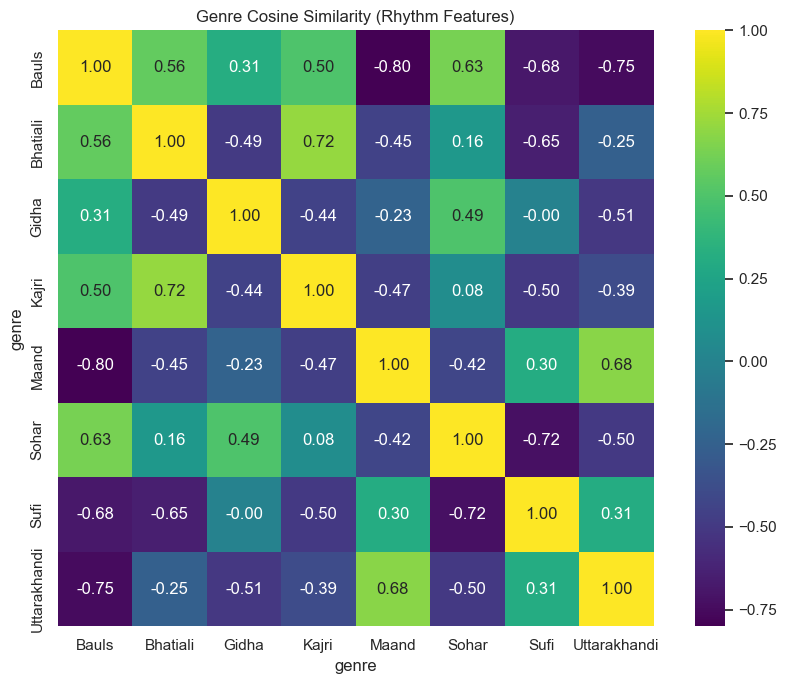

In [8]:
genre_cos_sim = group_cosine_similarity(rhythm_df, group_col="genre")

plt.figure(figsize=(9, 7))
sns.heatmap(genre_cos_sim, annot=True, fmt=".2f", cmap="viridis", square=True)
plt.title("Genre Cosine Similarity (Rhythm Features)")
plt.tight_layout()
plt.show()


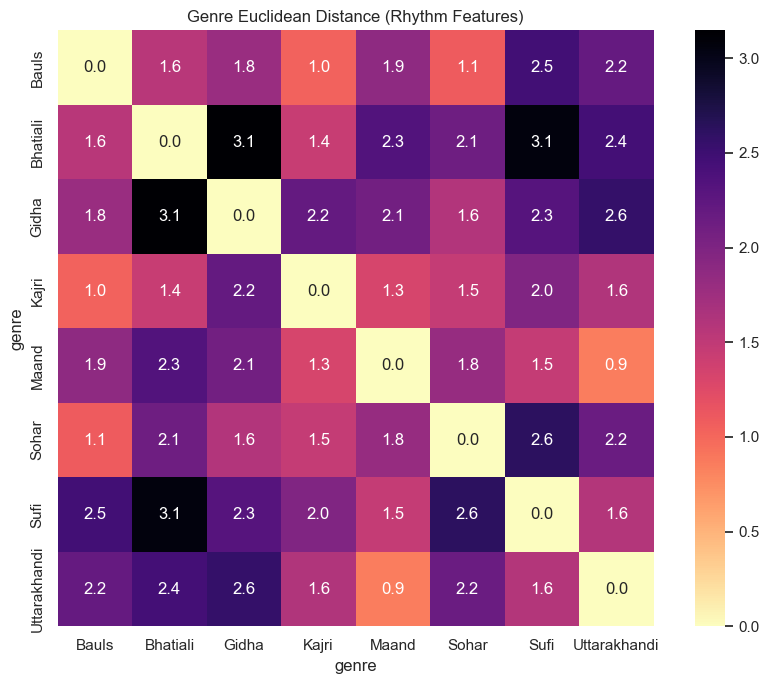

In [9]:
genre_dist = group_distance_matrix(rhythm_df, group_col="genre", metric="euclidean")

plt.figure(figsize=(9, 7))
sns.heatmap(genre_dist, annot=True, fmt=".1f", cmap="magma_r", square=True)
plt.title("Genre Euclidean Distance (Rhythm Features)")
plt.tight_layout()
plt.show()


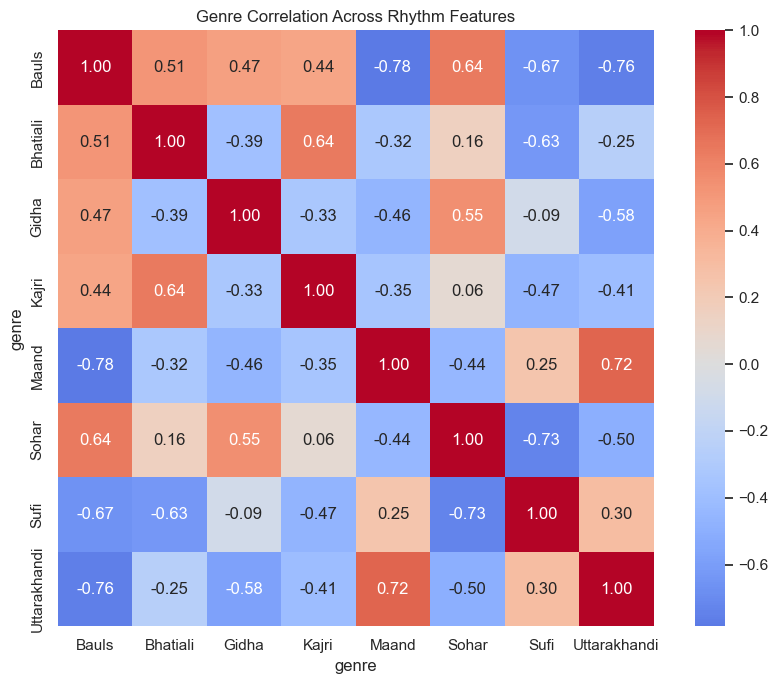

In [10]:
genre_corr = group_correlation_matrix(rhythm_df, group_col="genre")

plt.figure(figsize=(9, 7))
sns.heatmap(genre_corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, center=0)
plt.title("Genre Correlation Across Rhythm Features")
plt.tight_layout()
plt.show()


In [11]:
top_similar_pairs(genre_cos_sim, n=5)


,group_a,group_b,similarity
0,Bhatiali,Kajri,0.716452
1,Maand,Uttarakhandi,0.683451
2,Bauls,Sohar,0.627877
3,Bauls,Bhatiali,0.564350
4,Bauls,Kajri,0.499975


In [12]:
top_dissimilar_pairs(genre_cos_sim, n=5)


,group_a,group_b,similarity
0,Bauls,Maand,-0.800475
1,Bauls,Uttarakhandi,-0.745812
2,Sohar,Sufi,-0.723418
3,Bauls,Sufi,-0.682978
4,Bhatiali,Sufi,-0.646216


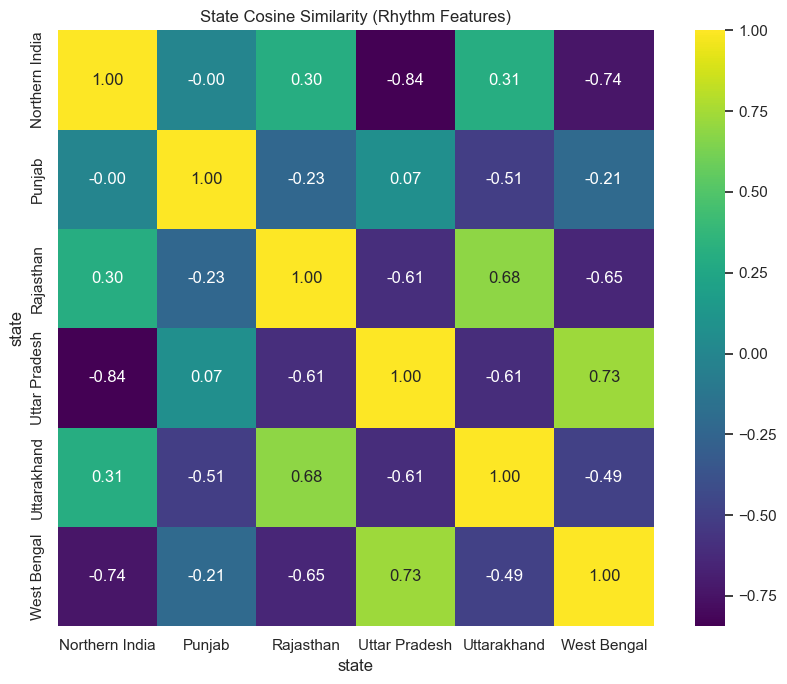

In [13]:
state_cos_sim = group_cosine_similarity(rhythm_df, group_col="state")

plt.figure(figsize=(9, 7))
sns.heatmap(state_cos_sim, annot=True, fmt=".2f", cmap="viridis", square=True)
plt.title("State Cosine Similarity (Rhythm Features)")
plt.tight_layout()
plt.show()


In [14]:
deviation_df = feature_wise_group_deviation(rhythm_df, group_col="genre")
deviation_df


,cross_group_std
energy_max,0.402290
energy_min,0.401751
energy_mean,0.399404
frame_entropy_mean,0.372654
flux_mean,0.316977
flux_sum,0.316977
onset_mean,0.307372
ac_peak_value,0.284644
tempogram_var,0.277635
onset_peak_count,0.272404


C:\Users\ankit\AppData\Local\Temp\ipykernel_44960\4285943272.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_deviation["cross_group_std"], y=top_deviation.index, palette="rocket")


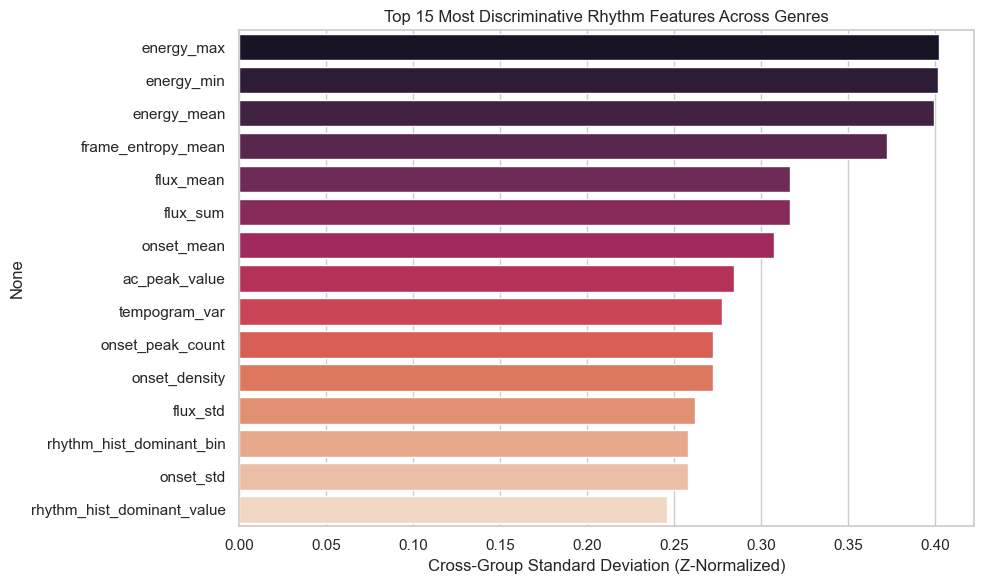

In [15]:
top_n = 15
top_deviation = deviation_df.head(top_n)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_deviation["cross_group_std"], y=top_deviation.index, palette="rocket")
plt.title(f"Top {top_n} Most Discriminative Rhythm Features Across Genres")
plt.xlabel("Cross-Group Standard Deviation (Z-Normalized)")
plt.tight_layout()
plt.show()


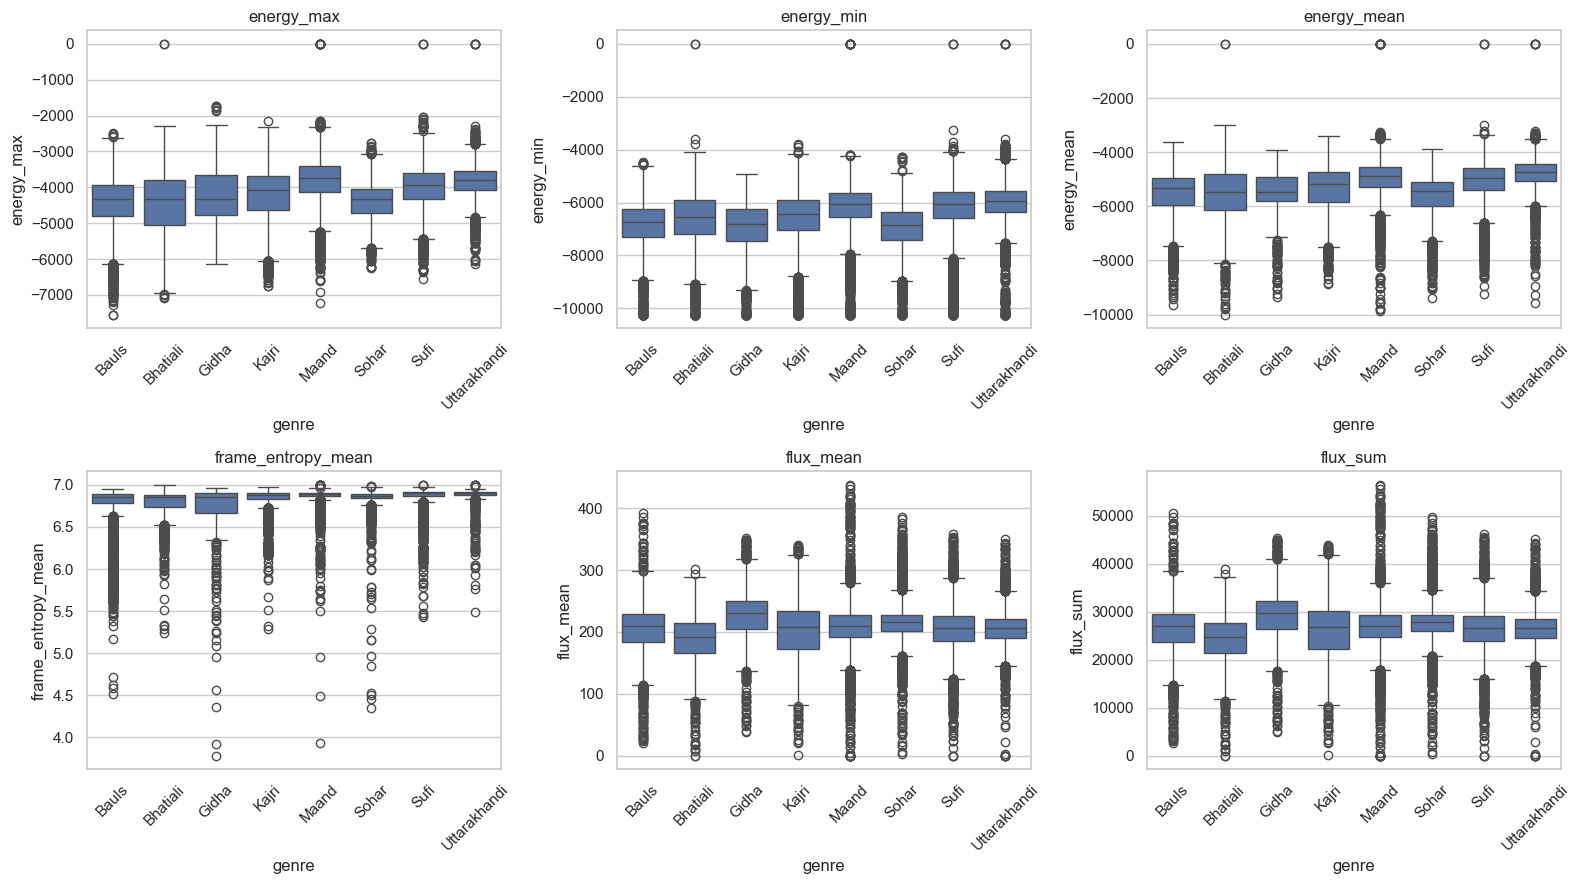

In [16]:
top_features = top_deviation.index[:6].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feat in zip(axes, top_features):
    sns.boxplot(data=rhythm_df, x="genre", y=feat, ax=ax)
    ax.set_title(feat)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


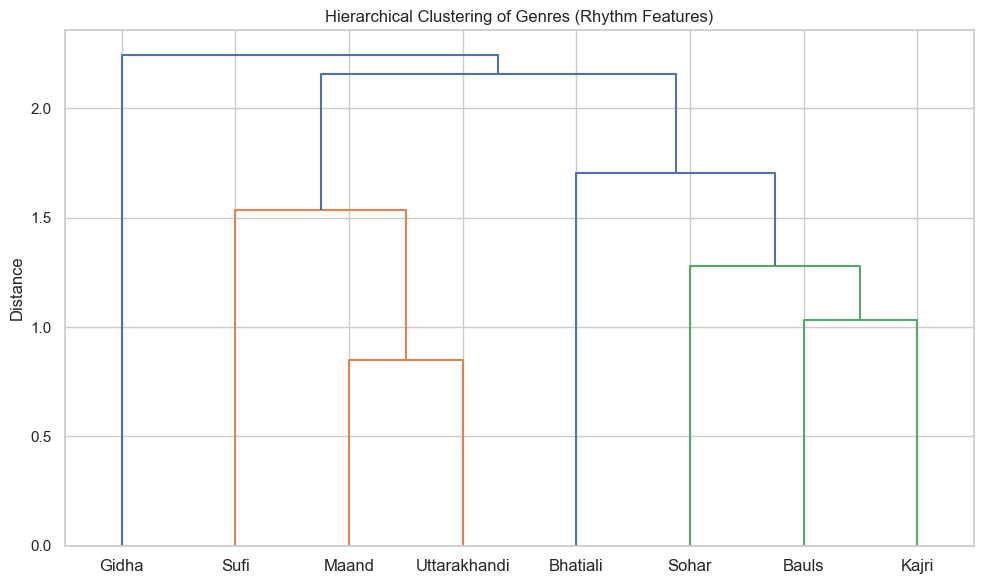

In [17]:
from scipy.cluster.hierarchy import linkage, dendrogram

genre_centroids_norm, _ = compute_group_centroids(rhythm_df, group_col="genre", normalize=True)
linkage_matrix = linkage(genre_centroids_norm.to_numpy(), method="average", metric="euclidean")

plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix, labels=genre_centroids_norm.index.tolist())
plt.title("Hierarchical Clustering of Genres (Rhythm Features)")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


### Observations on Rhythmic Features:
#### Rhythmic Spread (rhythm_hist_std): The rhythmic histogram standard deviation varies significantly. Sufi music exhibits a tight, strongly grouped rhythmic focus (rhythm_hist_std = -0.386), indicating dominant, repetitive percussive patterns. Conversely, Sohar shows a much wider, more chaotic rhythmic spread (rhythm_hist_std = 0.271).  
#### Tempo Stability (tempogram_var): The variance in the tempogram (tempogram_var) highlights clear stylistic differences. Bhatiali displays high tempo variance (0.564), reflecting fluid, unmetered, or rubato rhythmic structures. In stark contrast, Sufi music is incredibly stable and rigidly metered, with a variance of -0.409.  
#### Energy Dynamics (energy_std & energy_range): Gidha is characterized by explosive, highly dynamic rhythmic energy, marked by the highest energy standard deviation (0.368) and energy range (0.429).  
#### Onset Density (onset_density): The onset density metric cleanly separates the genres. Sufi music is the most rhythmically dense and percussively active (0.472). Bhatiali, on the other hand, is the most sparse and sustained (-0.332).  